In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
dane = pd.read_csv('WELFake_Dataset.csv')
dane.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


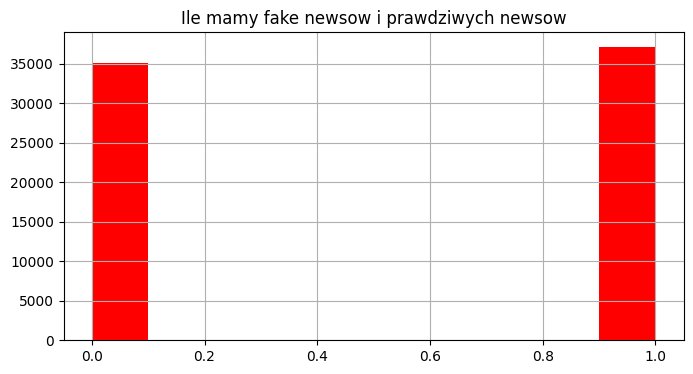

In [7]:
dane.label.hist(figsize=(8,4), color='red')
plt.title('Ile mamy fake newsow i prawdziwych newsow')
plt.grid(True)
plt.show()

In [22]:
dane.fillna({'title':'no title'}, inplace = True)
dane.text.dropna(inplace=True)
dane.isna().value_counts()

,,,,,,count
Unnamed: 0,title,text,label,title_len,text_len,
False,False,False,False,False,False,72095


<Axes: xlabel='label'>

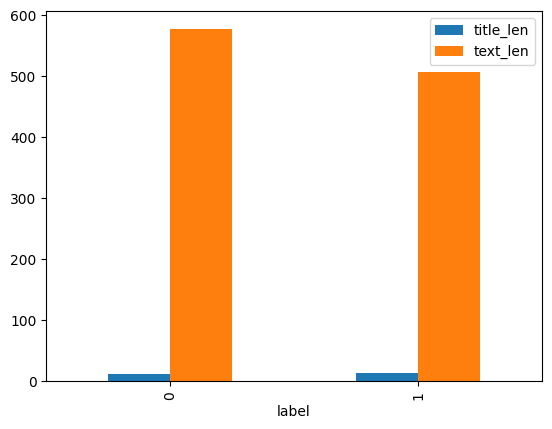

In [21]:
dane['title_len'] = dane['title'].apply(lambda x: len(x.split()))
dane['text_len'] = dane['text'].apply(lambda x: len(x.split()))

stats = dane.groupby('label')[['title_len', 'text_len']].mean()
stats.plot(kind='bar')

Widać, że dane są dobrze dobrane (mniej wiecej po połowie fake i real newsow), długosc tekstu prawdziwego jest o kilkanascie % dłuższa, usunąłem lub uzupełniłem brakujące dane, wiec dane są gotowe do trenowania naszego modelu,